In [2]:
# !pip install numpy scipy networkx matplotlib

import io, gzip, math, sys
from collections import Counter
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt

# Path to your file:
PATH = "Amazon0302.txt"     # or "Amazon0302.txt.gz"

def open_maybe_gzip(path):
    if path.endswith(".gz"):
        return io.TextIOWrapper(gzip.open(path, "rb"), encoding="utf-8")
    return open(path, "r", encoding="utf-8")


In [3]:
def load_edge_list(path):
    src, dst = [], []
    max_id = -1
    with open_maybe_gzip(path) as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            u, v = int(parts[0]), int(parts[1])
            if u == v:  # drop self-loops if any
                continue
            src.append(u); dst.append(v)
            if u > max_id: max_id = u
            if v > max_id: max_id = v
    if max_id < 0:
        raise ValueError("No edges found.")
    n = max_id + 1
    m = len(src)
    return np.array(src, dtype=np.int64), np.array(dst, dtype=np.int64), n, m

src, dst, n, m = load_edge_list(PATH)
print(f"Loaded n={n:,} nodes, m={m:,} directed edges")
print("Preview:", list(zip(src[:10], dst[:10])))


Loaded n=262,111 nodes, m=1,234,877 directed edges
Preview: [(np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(3)), (np.int64(0), np.int64(4)), (np.int64(0), np.int64(5)), (np.int64(1), np.int64(0)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(5)), (np.int64(1), np.int64(15))]


In [14]:
src[:5]

array([-1, -1, -1, -1, -1])

In [13]:
# Merge src and dst elementwise into a list of (src, dst) tuples
assert src.shape == dst.shape, "src and dst must have same length"
edges = [(int(u), int(v)) for u, v in zip(src, dst)]
print(f"Created {len(edges):,} edge tuples. Sample:", edges[:10])

Created 1,234,877 edge tuples. Sample: [(-1, 0), (-1, 1), (-1, 2), (-1, 3), (-1, 4), (0, -1), (0, 1), (0, 3), (0, 4), (0, 14)]


In [12]:
N = 5000

In [ ]:
A = np.zeros((N, N), dtype=np.uint8)
for i, j in mydata:
    if i<N and j<N:
        A[i, j] = 1

In [9]:
A[:5]

[(np.int64(-1), np.int64(0)),
 (np.int64(-1), np.int64(1)),
 (np.int64(-1), np.int64(2)),
 (np.int64(-1), np.int64(3)),
 (np.int64(-1), np.int64(4))]

In [8]:
def build_csr(src, dst, n):
    data = np.ones_like(src, dtype=np.int8)
    A = sp.csr_matrix((data, (src, dst)), shape=(n, n))
    return A

A = build_csr(src, dst, n)
print(A.shape, "nnz=", A.nnz)

# Degrees (directed)
out_deg = np.asarray(A.sum(axis=1)).ravel()
in_deg  = np.asarray(A.sum(axis=0)).ravel()

# Undirected projection (simple, binary)
A_und = (A + A.transpose()).astype(bool).astype(np.int8).tocsr()
und_deg = np.asarray(A_und.sum(axis=1)).ravel()

print("Sample nodes 0..9:")
for u in range(min(10, n)):
    print(f"  {u:>6d}: in={int(in_deg[u])} out={int(out_deg[u])} und={int(und_deg[u])}")


(262111, 262111) nnz= 1234877
Sample nodes 0..9:
       0: in=2 out=5 und=5
       1: in=1 out=5 und=5
       2: in=2 out=5 und=6
       3: in=1 out=5 und=6
       4: in=25 out=5 und=28
       5: in=54 out=5 und=56
       6: in=98 out=5 und=101
       7: in=34 out=5 und=37
       8: in=293 out=5 und=296
       9: in=20 out=0 und=20


In [9]:
def density_directed(n, m):
    denom = n * (n - 1)
    return (m / denom) if denom > 0 else 0.0

def density_undirected_from_csr(A_und_bool):
    # Count undirected edges once (symmetric 0/1)
    loops = int(A_und_bool.diagonal().sum())
    undirected_edges = (A_und_bool.nnz - loops) // 2
    denom = n * (n - 1) / 2
    return (undirected_edges / denom) if denom > 0 else 0.0

dens_dir = density_directed(n, m)
dens_und = density_undirected_from_csr(A_und)
print(f"Density (directed):   {dens_dir:.6e}")
print(f"Density (undirected): {dens_und:.6e}")


Density (directed):   1.797442e-05
Density (undirected): 2.619409e-05


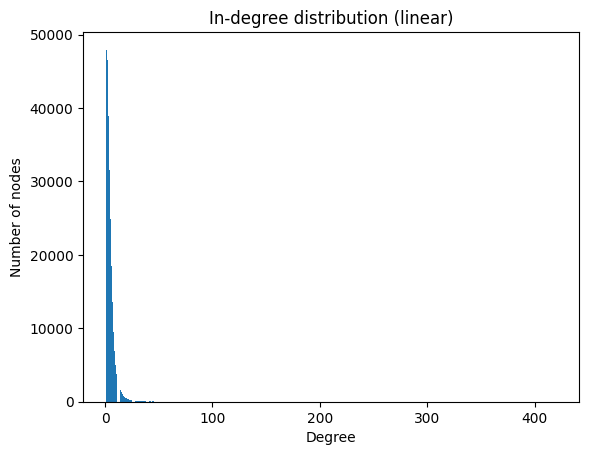

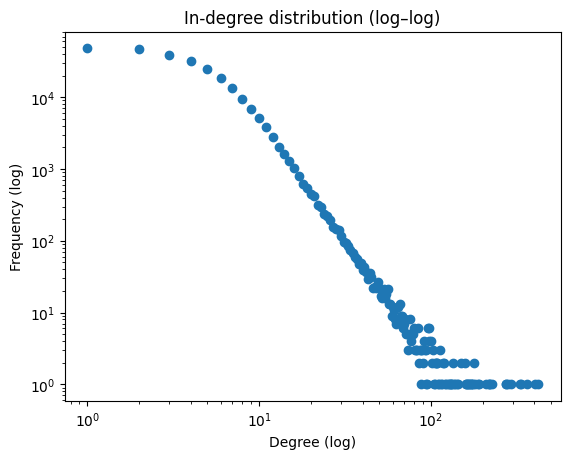

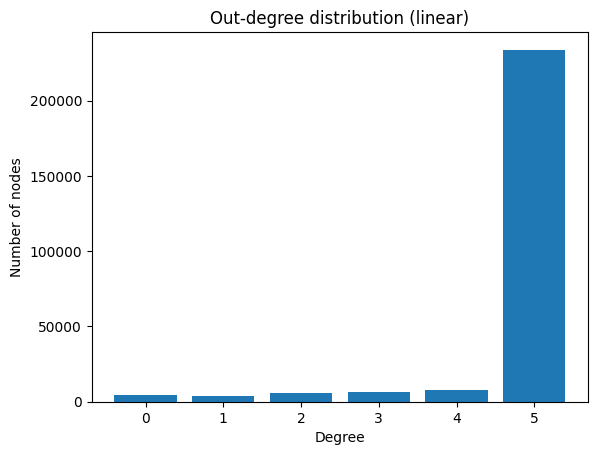

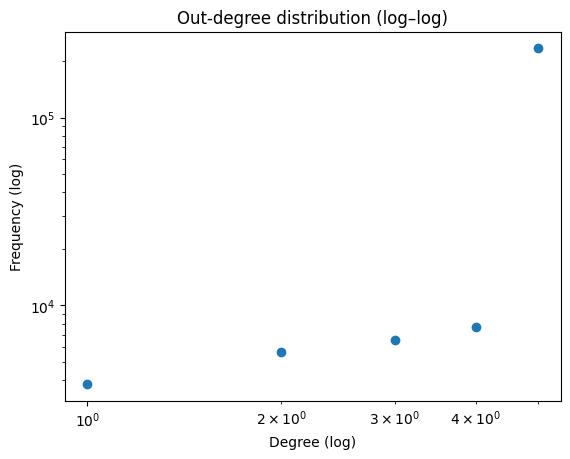

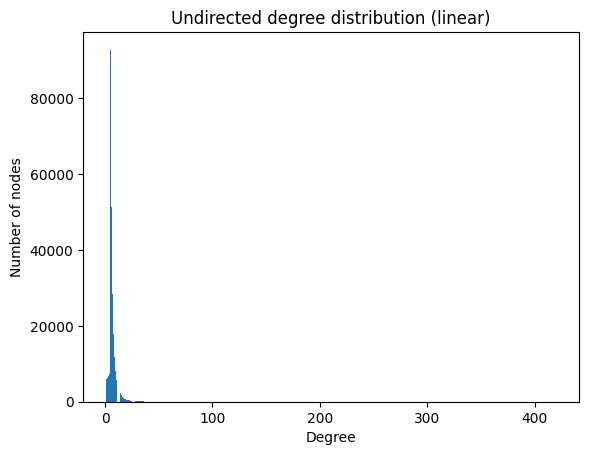

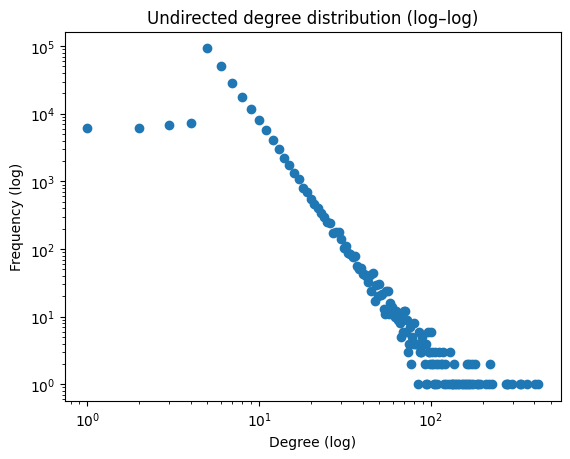

In [10]:
# Build degree counts
in_counts  = Counter(in_deg.tolist())
out_counts = Counter(out_deg.tolist())
und_counts = Counter(und_deg.tolist())

def plot_degree_distribution(counts, title):
    # Degree values (exclude 0 for log-log clarity if desired)
    degs = np.array(sorted(counts.keys()))
    freqs = np.array([counts[d] for d in degs])

    # Linear scale
    plt.figure()
    plt.bar(degs, freqs)
    plt.xlabel("Degree")
    plt.ylabel("Number of nodes")
    plt.title(f"{title} (linear)")
    plt.show()

    # Log–log (filter out zeros)
    mask = (degs > 0) & (freqs > 0)
    d_log = degs[mask]
    f_log = freqs[mask]
    plt.figure()
    plt.loglog(d_log, f_log, marker="o", linestyle="none")
    plt.xlabel("Degree (log)")
    plt.ylabel("Frequency (log)")
    plt.title(f"{title} (log–log)")
    plt.show()

plot_degree_distribution(in_counts,  "In-degree distribution")
plot_degree_distribution(out_counts, "Out-degree distribution")
plot_degree_distribution(und_counts, "Undirected degree distribution")


In [ ]:
# Manual transitivity (no networkx)
def transitivity_manual(A_und_bool):
    # A_und_bool: symmetric {0,1}, CSR or CSC
    A = A_und_bool.astype(np.float64)
    # count triangles using matrix power
    tri_mat = A @ A @ A
    triangles = tri_mat.diagonal().sum() / 6.0
    deg = np.asarray(A.sum(axis=1)).ravel()
    triplets = np.sum(deg * (deg - 1)) / 2.0
    T = (3 * triangles / triplets) if triplets > 0 else 0.0
    return float(T)

T_manual = transitivity_manual(A_und)
print("Manual transitivity:", T_manual)


In [13]:
# Build a simple undirected graph (NetworkX) without duplicates
G_und = nx.Graph()
G_und.add_nodes_from(range(n))
# Add each undirected edge once
edges_und = {(int(u), int(v)) if int(u) < int(v) else (int(v), int(u))
             for u, v in zip(src, dst) if int(u) != int(v)}
G_und.add_edges_from(edges_und)

trans = nx.transitivity(G_und)  # global clustering coefficient
print(f"Transitivity (undirected): {trans:.6e}")


Transitivity (undirected): 2.360827e-01


In [ ]:
from collections import deque

def bfs_distances(A_und, source):
    """Return array of shortest-path distances from source."""
    n = A_und.shape[0]
    dist = np.full(n, np.inf)
    dist[source] = 0
    q = deque([source])
    indptr, indices = A_und.indptr, A_und.indices
    while q:
        u = q.popleft()
        for v in indices[indptr[u]:indptr[u+1]]:
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def closeness_manual(A_und, nodes_subset=None):
    n = A_und.shape[0]
    if nodes_subset is None:
        nodes_subset = range(n)
    closeness = {}
    for u in nodes_subset:
        dist = bfs_distances(A_und, u)
        reachable = np.isfinite(dist)
        s = dist[reachable].sum()
        if s > 0 and reachable.sum() > 1:
            closeness[u] = (reachable.sum() - 1) / s
        else:
            closeness[u] = 0.0
    return closeness

# Example: compute for first 10 nodes
nodes_subset = list(range(10))
C_manual = closeness_manual(A_und, nodes_subset)
print("Manual closeness for first 10 nodes:")
for u, c in C_manual.items():
    print(f" node {u}: {c:.6e}")


In [14]:
# Closeness is expensive globally. We'll compute it exactly for top-K by undirected degree.
K_CLOSENESS = 100  # adjust to your patience/budget
topk_idx = np.argpartition(-und_deg, K_CLOSENESS)[:K_CLOSENESS]
topk_idx = topk_idx[np.argsort(-und_deg[topk_idx])]

closeness = {}
for u in topk_idx:
    closeness[u] = nx.closeness_centrality(G_und, u=u)

top_close = sorted(closeness.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top closeness (subset):")
for i, (u, c) in enumerate(top_close, 1):
    print(f"  {i:2d}. node {u}  closeness={c:.6e}  undeg={int(und_deg[u])}")


Top closeness (subset):
   1. node 4429  closeness=1.880131e-01  undeg=405
   2. node 33  closeness=1.837966e-01  undeg=363
   3. node 93  closeness=1.835356e-01  undeg=221
   4. node 297  closeness=1.825445e-01  undeg=280
   5. node 2501  closeness=1.810767e-01  undeg=194
   6. node 2353  closeness=1.796825e-01  undeg=180
   7. node 5765  closeness=1.786570e-01  undeg=210
   8. node 3589  closeness=1.762500e-01  undeg=132
   9. node 8  closeness=1.760305e-01  undeg=296
  10. node 5120  closeness=1.744037e-01  undeg=95


In [17]:
# Betweenness is heavy; we use k-sample approximation.
K_BETW = 512  # increase for more accuracy, but it gets slower
np.random.seed(42)

# Compatibility for different networkx versions
if hasattr(nx, "betweenness_centrality"):
    betw = nx.betweenness_centrality(G_und, k=K_BETW, seed=42, normalized=True)
else:
    # fallback in case of very old version
    from networkx.algorithms import approximation
    betw = approximation.betweenness_centrality(G_und, k=K_BETW, seed=42, normalized=True)

top_betw = sorted(betw.items(), key=lambda kv: kv[1], reverse=True)[:10]
print(f"Top betweenness (approx, k={K_BETW}):")
for i, (u, b) in enumerate(top_betw, 1):
    print(f"  {i:2d}. node {u}  betweenness={b:.6e}  undeg={int(und_deg[u])}")


KeyboardInterrupt: 

In [16]:
# Save numeric arrays fast
np.savez_compressed(
    "amazon_metrics.npz",
    in_deg=in_deg,
    out_deg=out_deg,
    und_deg=und_deg,
    n=np.array([n]),
    m=np.array([m]),
    transitivity=np.array([trans], dtype=float)
)

print("Saved arrays to amazon_metrics.npz")


Saved arrays to amazon_metrics.npz


In [ ]:
# Cell 3: number of unique nodes and the maximum node id
num_unique = len(set(itertools.chain.from_iterable()))
max_id = max(set(itertools.chain.from_iterable(mydata)))
num_unique, max_id
